In [13]:
import os
from dotenv import load_dotenv
load_dotenv()
import sqlite3
from typing import TypedDict, Annotated, List
import uuid

# --- Gradio for the UI ---
import gradio as gr
# --- LangChain & LangGraph Imports ---
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langchain_core.tools import tool
from langchain_community.utilities import SQLDatabase
from langchain_community.tools.sql_database.tool import InfoSQLDatabaseTool
# from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openrouter import ChatOpenRouter
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
# from langgraph.checkpoint.sqlite import SqliteSaver
from IPython.display import Image,display
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import Tool
from langchain_community.tools.file_management.write import WriteFileTool



In [14]:
print(os.getenv("GEMINI_API_KEY") is not None)

True


In [15]:
db_file = "company_final_app.db"
conn = sqlite3.connect(db_file, check_same_thread=False)
cursor = conn.cursor()
cursor.execute("""
CREATE TABLE IF NOT EXISTS departments (
    id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    budget INTEGER
)""")
cursor.execute("""
CREATE TABLE IF NOT EXISTS employees (
    id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    department_id INTEGER,
    salary INTEGER
)""")
cursor.execute("INSERT OR IGNORE INTO departments (id, name, budget) VALUES (1, 'Engineering', 500000)")
cursor.execute("INSERT OR IGNORE INTO departments (id, name, budget) VALUES (2, 'Sales', 300000)")
cursor.execute("INSERT OR IGNORE INTO employees (id, name, department_id, salary) VALUES (1, 'Alice', 1, 95000)")
cursor.execute("INSERT OR IGNORE INTO employees (id, name, department_id, salary) VALUES (2, 'Bob', 2, 80000)")
conn.commit()
conn.close()


In [16]:
class State(TypedDict):
    messages: Annotated[list,add_messages]
    conversation_context: str  # Add this to maintain context


In [17]:
db = SQLDatabase.from_uri(f"sqlite:///{db_file}")

In [18]:
run_query=Tool(
    name="run_tool",
    func=db.run,
    description="Used to run SQL queries"
)

info_tool = Tool(
    name="info_tool",
    func=lambda table: db.get_table_info([table.strip()]),
    description="Use this tool to get column names and types of all tables in the database. Useful when the user asks about schema, columns, or structure of tables."
)


def list_tables(_: str = ""):
    return db.get_usable_table_names()

list_table = Tool(
    name="list_tool",
    func=list_tables,
    description="Use this tool to get all table names in the database. Useful for questions like 'how many tables are there?', 'list all tables', or 'what tables exist?'"
)


In [19]:
tools = [run_query, info_tool,list_table]

In [20]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

print("Key loaded:", os.getenv("OPENROUTER_API_KEY") is not None)

Key loaded: True


In [21]:
test_llm = ChatOpenRouter(
    model="openrouter/auto",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    temperature=0
)

response = test_llm.invoke("Say hello in one sentence.")
print(response.content)

Hello, I hope you're having a great day.


In [22]:
# llm = ChatGoogleGenerativeAI(
#     model="gemini-3.6-flash",
#     google_api_key=os.getenv("GEMINI_API_KEY")
# )
llm = ChatOpenRouter(
    model="openrouter/auto",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    temperature=0
)
llm_with_tools = llm.bind_tools(tools, tool_choice="auto")
def runner_agent(state: State):
    """This agent's ONLY job is to use its tools to get data."""
    context = state.get("conversation_context", "")

    system_prompt = f"""You are a seasoned SQL professional. Your goal is to answer the user's question by using your tools.
Conversation Context: {context}

**IMPORTANT**: Your final response must be based *directly* on the information returned from your tools.
- Do not describe your own actions.
- Do not say "I ran the query".
- If a tool returns data, state that data clearly.
- If you are asked about queries indirectly, check in the conversation context for more info
- Consider the conversation context when interpreting questions like "name them", "show them", "list them"
- If you are asked about the database as a whole like "total tables" use the list tool

**Example:**
- User asks: "Who has the highest salary?"
- Tool returns: "[('Alice', 95000)]"
- Your final answer should be: "The employee with the highest salary is Alice."
**Example 2:**
- Previous context: User asked about department count, result was 2 departments
- User asks: "name them"
- You should understand they want the names of those 2 departments
"""

    # Use the simple tool-bound LLM. DO NOT use with_structured_output here.
    response = llm_with_tools.invoke([SystemMessage(content=system_prompt)] + state["messages"])
    current_question = state["messages"][-1].content if state["messages"] else ""
    updated_context = f"{context}\nUser asked: {current_question}"



    # Return the full AI message, which will include any tool calls
    return {
        "messages": [response],
        "conversation_context": updated_context
    }

In [23]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    google_api_key=os.getenv("GEMINI_API_KEY")
)

NameError: name 'ChatGoogleGenerativeAI' is not defined

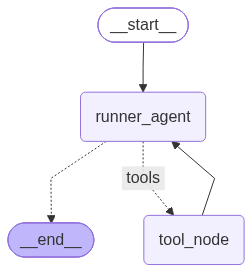

In [ ]:
graph_builder = StateGraph(State)

graph_builder.add_node("runner_agent",runner_agent)
graph_builder.add_node("tool_node",ToolNode(tools=tools))

graph_builder.add_conditional_edges(
    "runner_agent",
    tools_condition,
    {
        # If the agent wants to call a tool, route to the 'tool_node'
        "tools": "tool_node",
        # Otherwise, the graph execution is finished
        END: END
    }
)
graph_builder.add_edge("tool_node","runner_agent")
graph_builder.set_entry_point("runner_agent")

memory = MemorySaver() # Switched to a persistent saver
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
SESSION_ID = str(uuid.uuid4())

def chat(user_input: str, history: list):
    # Use a unique ID for each conversation session
    thread_id = str(hash(str(history)))
    config = {"configurable": {"thread_id": SESSION_ID}}

    # The initial input for the graph
    input_message = {
        "messages": [("user", user_input)],
    }

    # Call the graph and get the final state
    final_state = graph.invoke(input_message, config=config)

    # The final answer is in the last message of the final state
    final_answer = final_state["messages"][-1].content

    return final_answer

gr.ChatInterface(
    chat,
    title="Advanced SQL Database Assistant 🤖",
    description="Ask me questions about the company database!"
).launch()

/Users/timemachine/Desktop/github/SQLMate/.venv/lib/python3.11/site-packages/gradio/chat_interface.py:345: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [ ]:
result = graph.invoke(
    {"messages": [("user", "Who has the highest salary?")]},
    config={"configurable": {"thread_id": str(uuid.uuid4())}}
)

print(result["messages"][-1].content)

The employee with the highest salary is Alice, with a salary of $95,000.


In [ ]:

import os
from dotenv import load_dotenv

load_dotenv(override=True)

key = os.getenv("GEMINI_API_KEY")

print("Key exists:", key is not None)
print("Key starts with AQ.:", key.startswith("AQ.") if key else False)
print("Key length:", len(key) if key else 0)

Key exists: True
Key starts with AQ.: True
Key length: 53


In [ ]:
pip install -U langchain-openrouter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 1.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.3/837.3 kB 2.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 3.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 3.2 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.46.4
    Uninstalling pydantic_core-2.46.4:
      Successfully uninstalled pydantic_core-2.46.4
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.13.4
    Uninstalling pydantic-2.13.4:
      Successfully uninstalled pydantic-2.13.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.38.0 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.
langchain 0.3.26 requires lang